<a href="https://colab.research.google.com/github/radhasundar/datamining/blob/main/exercise10b_kmeans_clustering_mall_customers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Excercise 10b- K-Means -Clustering - mall customers data**

import the necessary libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler



In [ ]:
df=pd.read_excel("MallCustomers.xlsx")

create the dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Education               200 non-null    object
 4   Marital Status          200 non-null    object
 5   Annual Income (k$)      200 non-null    int64 
 6   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 11.1+ KB


In [ ]:
df.shape

(200, 7)

In [ ]:
df.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100)
0,1,M,19,High School,Married,15,39
1,2,M,21,Graduate,Single,15,81
2,3,F,20,Graduate,Married,16,6
3,4,F,23,High School,Unknown,16,77
4,5,F,31,Uneducated,Married,17,40


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


check for null values

In [ ]:
df.isnull().any()

,0
CustomerID,False
Gender,False
Age,False
Education,False
Marital Status,False
Annual Income (k$),False
Spending Score (1-100),False


Feature selection

In [ ]:
X=df[['Annual Income (k$)','Spending Score (1-100)']]

In [ ]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


Feature scaling

In [ ]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [ ]:
X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

In [ ]:
# print standardized values
print("\n standardized data: ")
print(X_scaled)


 standardized data: 
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]
 [-1.66266033  1.00159627]
 [-1.62449091 -1.71591298]
 [-1.62449091  1.70038436]
 [-1.58632148 -1.83237767]
 [-1.58632148  0.84631002]
 [-1.58632148 -1.4053405 ]
 [-1.58632148  1.89449216]
 [-1.54815205 -1.36651894]
 [-1.54815205  1.04041783]
 [-1.54815205 -1.44416206]
 [-1.54815205  1.11806095]
 [-1.50998262 -0.59008772]
 [-1.50998262  0.61338066]
 [-1.43364376 -0.82301709]
 [-1.43364376  1.8556706 ]
 [-1.39547433 -0.59008772]
 [-1.39547433  0.88513158]
 [-1.3573049  -1.75473454]
 [-1.3573049   0.88513158]
 [-1.24279661 -1.4053405 ]
 [-1.24279661  1.23452563]
 [-1.24279661 -0.7065524 ]
 [-1.24279661  0.41927286]
 [-1.20462718 -0.74537397]
 [-1.20462718  1.42863343]
 [-1.16645776 -1.7935561 ]
 [-1.16645776  0.88513158]
 [-1.05194947 -1.7935561 ]
 [-1.05194947  1.62274124]
 [-1.05194947 -1.4053405 ]
 [-1.05194947  1.19570407]
 [-1.0

In [ ]:
# Create K-Means model
kmeans=KMeans(n_clusters=5,random_state=42,n_init=10)

In [ ]:
#perform clustering
clusters=kmeans.fit_predict(X_scaled)


Evaluate clustering using Silhoutte score

In [ ]:
score=silhouette_score(X_scaled,clusters)

In [ ]:
print('Silhouette Score: ', score)

Silhouette Score:  0.5546571631111091


Interpreting the Overall Score (Average)
0.71 - 1.0: A strong and clear cluster structure has been found.
0.51-0.70: A reasonable or decent cluster structure is present.
0.26- 0.50: The cluster structure is weak and may be artificial.
Below 0.25: There is no substantial or meaningful cluster structure

In [ ]:
# display clustered centroids
print("\n cluster centroid: ")
print(kmeans.cluster_centers_)


 cluster centroid: 
[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


Add cluster labels to the dataset

In [ ]:
df['Cluster']=clusters

In [ ]:
df.head()

,CustomerID,Gender,Age,Education,Marital Status,Annual Income (k$),Spending Score (1-100),Cluster
0,1,M,19,High School,Married,15,39,4
1,2,M,21,Graduate,Single,15,81,2
2,3,F,20,Graduate,Married,16,6,4
3,4,F,23,High School,Unknown,16,77,2
4,5,F,31,Uneducated,Married,17,40,4


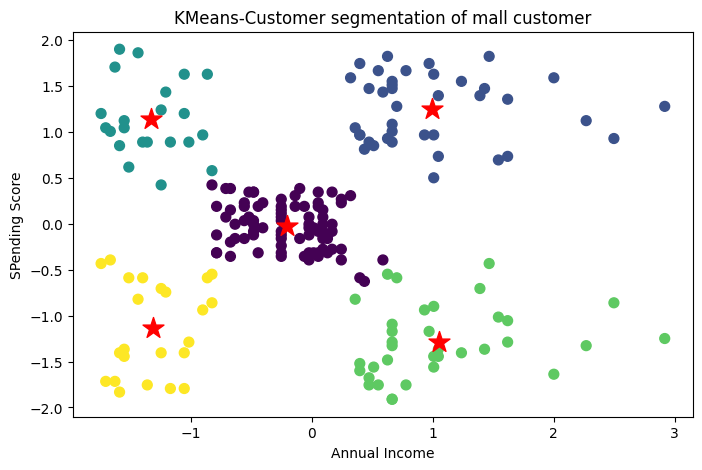

In [ ]:
#plot the clusters
plt.figure(figsize=(8,5))
plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=clusters,
    cmap="viridis",
   s=50
)


#plot cluster centroids
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    marker="*",
    s=250,
    color="red"
)
plt.xlabel("Annual Income")
plt.ylabel("SPending Score")
plt.title("KMeans-Customer segmentation of mall customer")
plt.legend
plt.show()

In [ ]:
df.groupby("Cluster")[["Annual Income (k$)","Spending Score (1-100)"]].mean()


,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [ ]:
df.groupby("Cluster")[['Gender','Age']]

Interpretation
Cluster	Interpretation
Cluster 0	Customers with medium income and medium spending.
Cluster 1	Customers with high income and high spending (Premium Customers).
Cluster 2	Customers with low income but high spending.
Cluster 3	Customers with high income but low spending.
Cluster 4	Customers with low income and low spending.